## Postprocessing for Lithium Oxide Pellet Bed Release Model ##

Import results

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# --- 1. LOAD DATA FROM JSON FILE ---
# Define Results folder path
results_folder = "/home/Repositories/BABY-LiOx/analysis/tritium/Results"
results_file = os.path.join(results_folder, "LiOx_pellet_results.json")

print(f"--- Loading data from {results_file} ---")

with open(results_file, 'r') as f:
    data = json.load(f)

# Extract parameters and results from the loaded data
params = data['simulation_parameters']
results = data['simulation_results']

# --- 2. RECONSTRUCT VARIABLES FOR PLOTTING ---
decay_constant = 1.785e-9 # Tritium Decay Constant (1/s)

# Simulation parameters
r_g = params['grain_radius']
r_p = params['pellet_radius']
pellet_porosity = params['pellet_porosity']
packing_density = params['packing_density']
r_bed = params['bed_radius']
z_bed = params['bed_length']
D = params['diffusion_coeff']
k_grain_ads = params['adsorption_coeff']
k_grain_des = params['desorption_coeff']
kt = params['trapping_coeff']
kd = params['detrapping_coeff']
Nt = params['trap_density']
source_rate = params['source_rate']
tbr = params['tritium_breeding_ratio']
G_rate = params['tritium_generation_rate']
Q_sparge = params['sparge_flow']
t_irr = params['irradiation_time_s']
total_sim_time = params['total_sim_time_s']
N = params['radial_nodes_grain']
Nz = params['axial_nodes_bed']

# Time-series results
time_points = results['time_s']
time_days = results['time_days']
total_inventory_history = results['total_inventory']
grain_inventory_history = results['grain_inventory']
bed_release_rate_history = results['bed_release_rate']
grain_release_rate_history = results['grain_release_rate']
C_pore_outlet_history = results['outlet_pore_concentration']
C_sparge_outlet_history = results['outlet_sparge_concentration']
total_generated_history = results['total_generated_tritium']
cumulative_release_history = results['cumulative_release']
grain_radial_positions = results['grain_radial_positions']
dt_history = results['adaptive_timestep']
rel_change_history = results['max_relative_change']
adaptive_timestep = results['adaptive_timestep']
max_relative_change = results['max_relative_change']
key_times = np.array(results['key_times'])

# Profile results
C_sparge_profile_history = results['sparge_gas_axial_profiles']
Cm_history = np.array(results['grain_mobile_concentration_profile_inlet'])


# Reconstruct spatial grids
# Radial grid for the grain model
r = np.linspace(0, r_g, N + 1)
# Axial grid for the packed bed model
dz = z_bed / Nz
z = np.linspace(dz/2, z_bed - dz/2, Nz)

# Reconstruct other necessary arrays
# The time interval 'dt' for each step, needed for cumulative sum
data_intervals = np.diff(time_points, prepend=0)

print("--- Data loaded and variables reconstructed successfully ---\n")


--- Loading data from /home/Repositories/BABY-LiOx/analysis/tritium/Results/LiOx_pellet_results.json ---
--- Data loaded and variables reconstructed successfully ---



Total Inventory & Cumulative Release

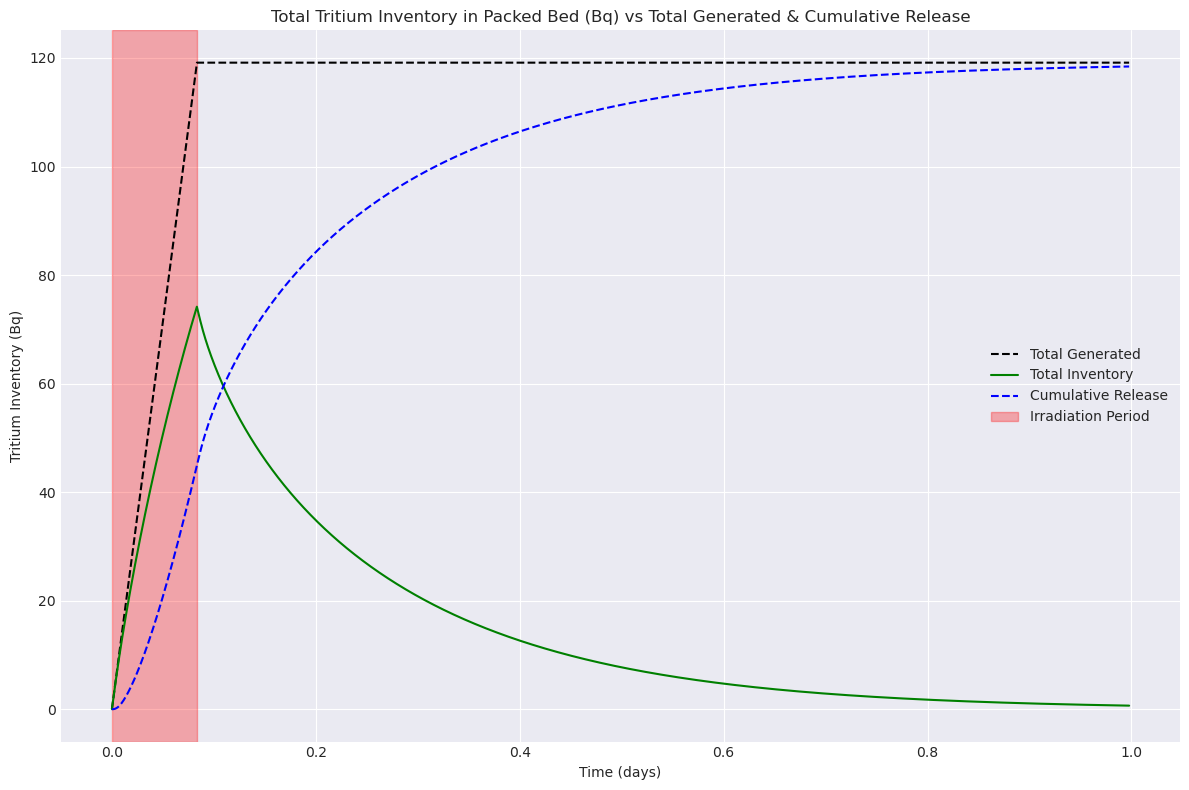

In [65]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure and axes object
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data
ax.plot(time_days, total_generated_history, 'k--', label='Total Generated')
ax.plot(time_days, total_inventory_history, 'g-', label='Total Inventory')
ax.plot(time_days, cumulative_release_history, 'b--', label='Cumulative Release')

# Set labels and title
ax.set_xlabel('Time (days)')
ax.set_ylabel('Tritium Inventory (Bq)')
ax.set_title('Total Tritium Inventory in Packed Bed (Bq) vs Total Generated & Cumulative Release')

ax.ticklabel_format(axis='y', style='plain')
ax.axvspan(0, t_irr/86400, color='red', alpha=0.3, label='Irradiation Period')
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

Bed Release Rate

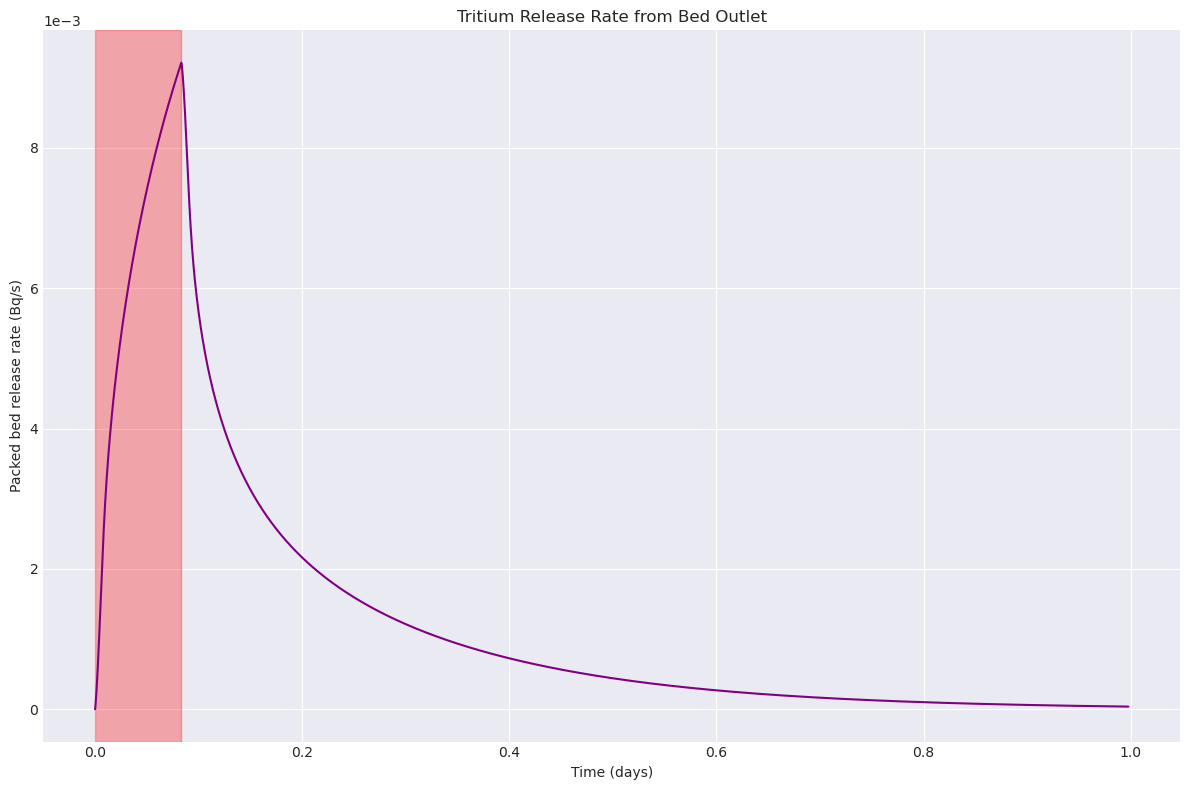

In [66]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(time_days, bed_release_rate_history, color='purple')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Packed bed release rate (Bq/s)')
ax.set_title('Tritium Release Rate from Bed Outlet')

ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.axvspan(0, t_irr/86400, color='red', alpha=0.3)
ax.grid(True)

fig.tight_layout()
plt.show()

Sparge & Pore Gas Concentrations at Outlet

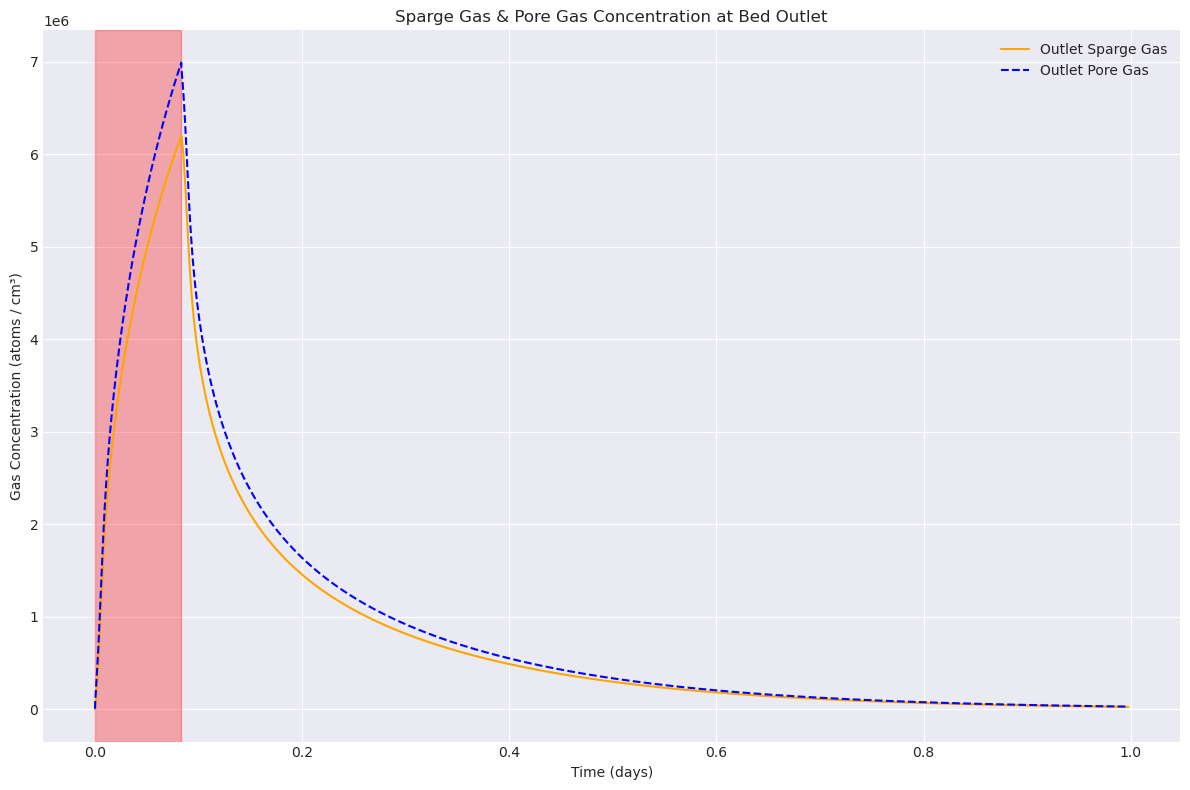

In [67]:

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(time_days, C_sparge_outlet_history, label='Outlet Sparge Gas', color='orange')
ax.plot(time_days, C_pore_outlet_history, label='Outlet Pore Gas', color='blue', linestyle='--')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Gas Concentration (atoms / cm³)')
ax.set_title('Sparge Gas & Pore Gas Concentration at Bed Outlet')

ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.axvspan(0, t_irr/86400, color='red', alpha=0.3)

ax.legend(loc='upper right')
ax.grid(True)

fig.tight_layout()
plt.show()

Sparge Gas Axial Concentration Profile

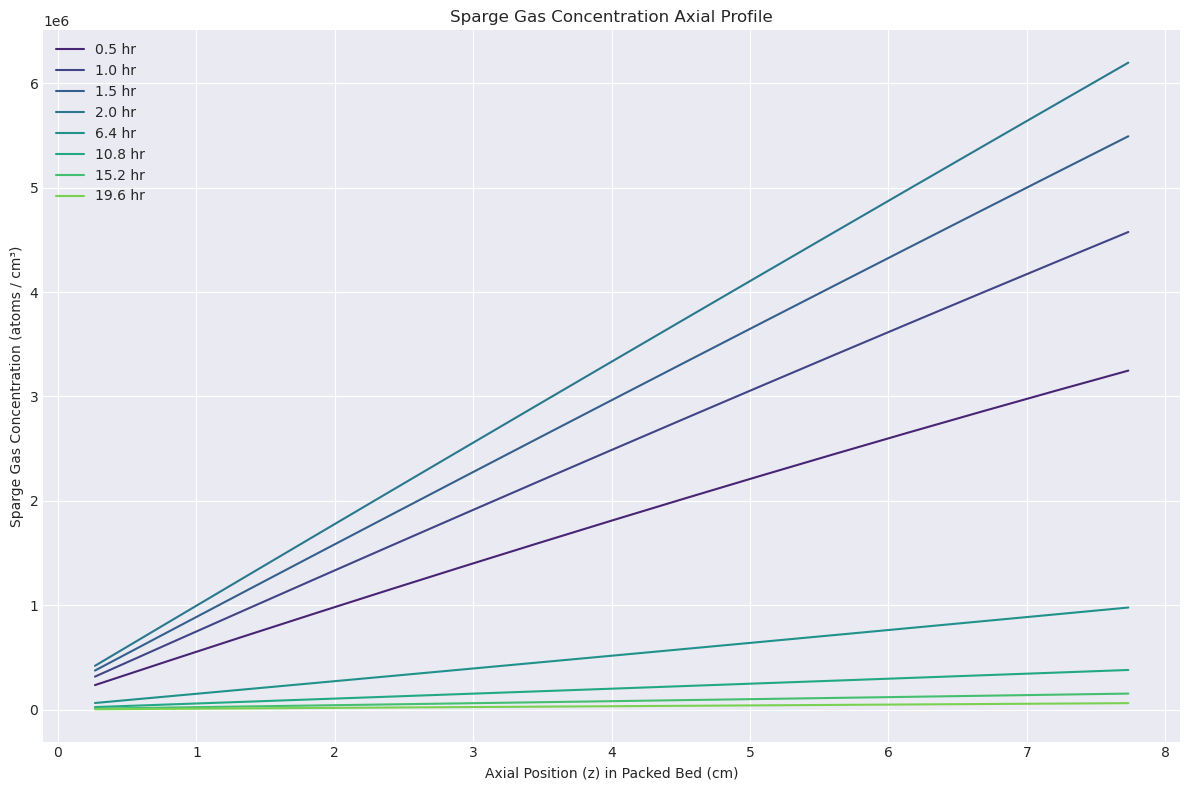

In [68]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(key_times) + 1))
i=0
for label, profile in C_sparge_profile_history.items():
    i += 1
    ax.plot(z, profile, color=colors[i], label=label)

ax.set_xlabel('Axial Position (z) in Packed Bed (cm)')
ax.set_ylabel('Sparge Gas Concentration (atoms / cm³)')
ax.set_title('Sparge Gas Concentration Axial Profile')

ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()


Concentration Profile Within Grain (at Inlet)

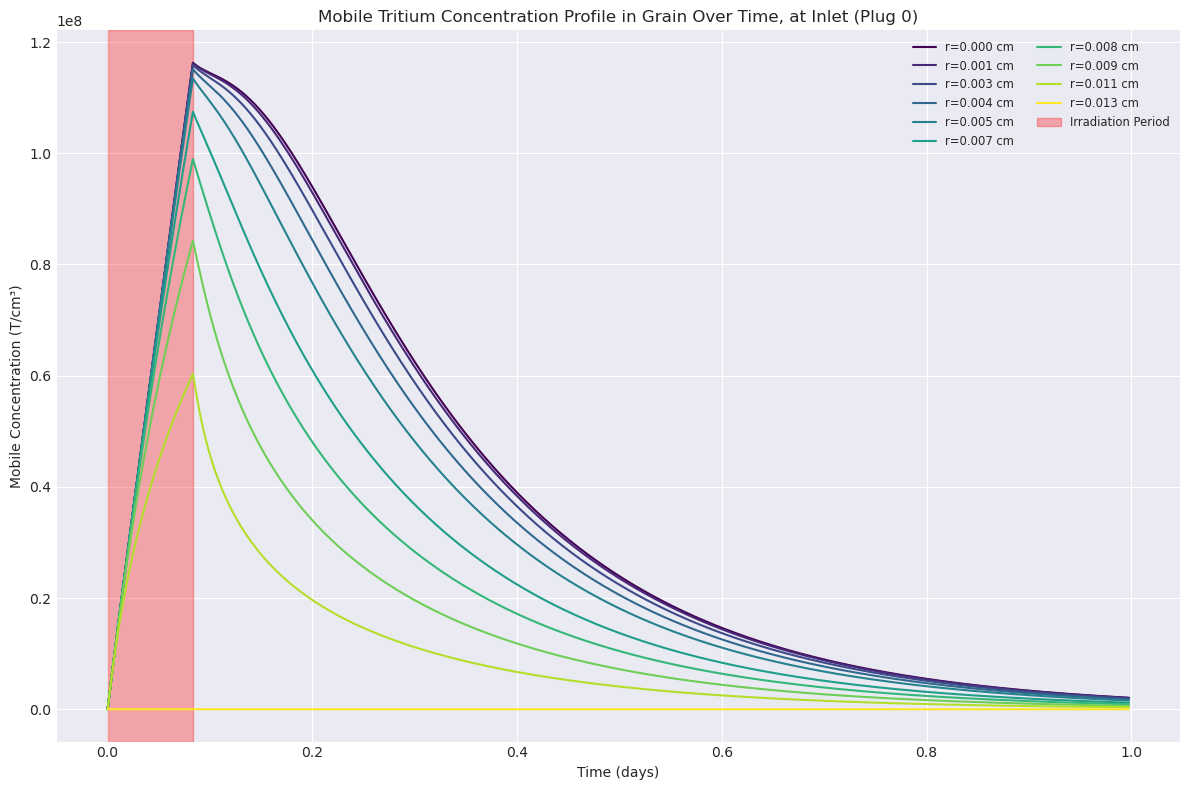

In [69]:
fig, ax = plt.subplots(figsize=(12, 8))

# Select 5 radial positions equally spaced from centre (index 0) to surface (index N)
selected_indices = np.linspace(0, N, 10).astype(int)
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_indices)))
for k, idx in enumerate(selected_indices):
    ax.plot(time_days, Cm_history[:, idx], color=colors[k], label=f"r={r[idx]:.3f} cm")

ax.set_xlabel('Time (days)')
ax.set_ylabel('Mobile Concentration (T/cm³)')
ax.set_title('Mobile Tritium Concentration Profile in Grain Over Time, at Inlet (Plug 0)')

ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.axvspan(0, t_irr/86400, color='red', alpha=0.3, label='Irradiation Period')
ax.legend(fontsize='small', ncol=2)
ax.grid(True)

fig.tight_layout()
plt.show()

Mass Balance Check

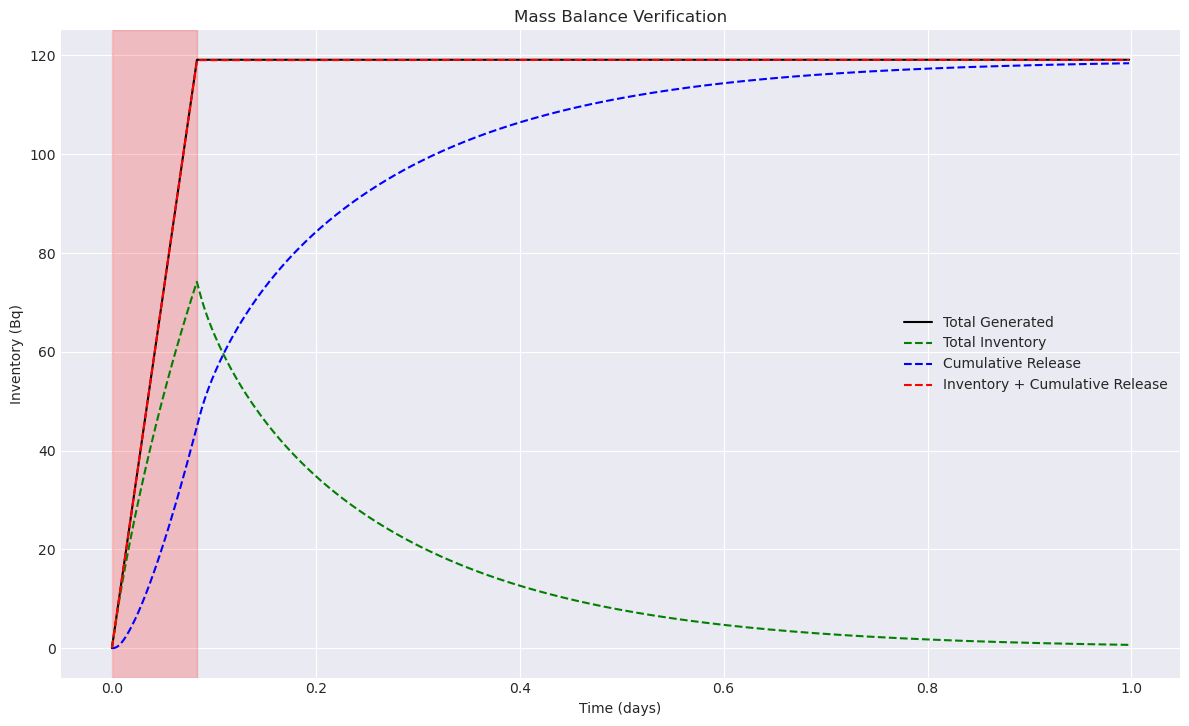

In [70]:
fig, ax = plt.subplots(figsize=(12, 8))

inventory_plus_release = np.array(total_inventory_history) + np.array(cumulative_release_history)

ax.plot(time_days, total_generated_history, 'k-', label='Total Generated')
ax.plot(time_days, total_inventory_history, 'g--', label='Total Inventory')
ax.plot(time_days, cumulative_release_history, 'b--', label='Cumulative Release')
ax.plot(time_days, inventory_plus_release, 'r--', label='Inventory + Cumulative Release')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Inventory (Bq)')
ax.set_title('Mass Balance Verification')
ax.ticklabel_format(axis='y', style='plain')
ax.axvspan(0, t_irr/86400, color='red', alpha=0.2)
ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Single Grain (at Inlet) Release Rate & Cumulative Release

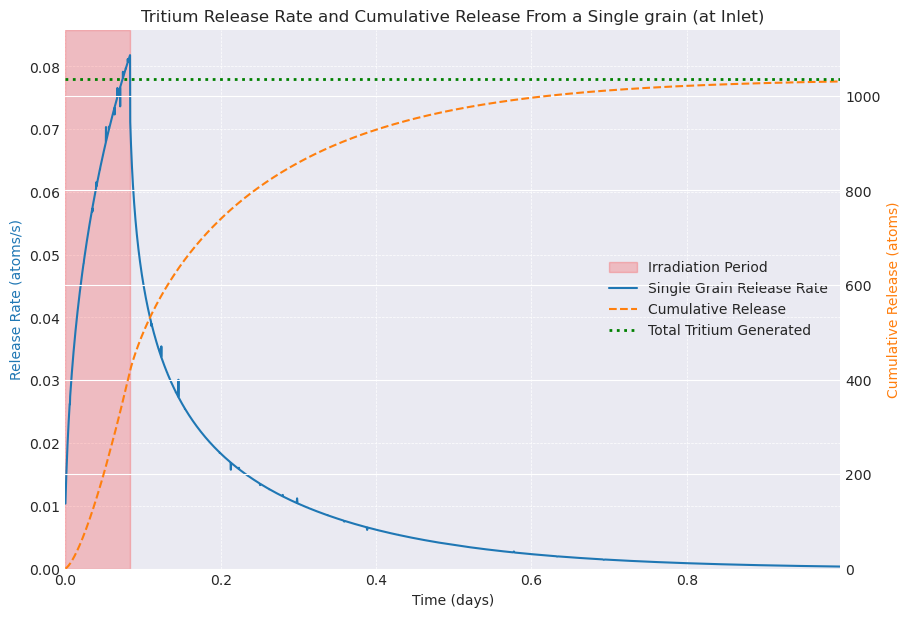

In [73]:

fig, ax = plt.subplots(figsize=(10, 7))
    
ax.axvspan(0, t_irr / (86400), color='red', alpha=0.2, label='Irradiation Period')

# Plot grain release rate at inlet
ax.plot(time_days, grain_release_rate_history, linestyle='-', color='tab:blue', label='Single Grain Release Rate')
ax.set_title('Tritium Release Rate and Cumulative Release From a Single grain (at Inlet)')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Release Rate (atoms/s)', color='tab:blue')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0, right=max(time_days))

grain_cumulative_release = np.cumsum(grain_release_rate_history * data_intervals)  # Cumulative release from a single grain

# Secondary y-axis for cumulative release
axb = ax.twinx()
axb.plot(time_days, grain_cumulative_release, color='tab:orange', linestyle='--', label='Cumulative Release')
axb.set_ylabel('Cumulative Release (atoms)', color='tab:orange')
axb.set_ylim(bottom=0)

# Add horizontal line for total tritium generated during irradiation
grain_volume = (4/3) * np.pi * r_g**3
total_generated = G_rate * t_irr * grain_volume
axb.axhline(total_generated, color='green', linestyle=':', linewidth=2, label='Total Tritium Generated')
axb.set_ylim(top=1.1 * total_generated)  # Set upper limit to 110% of total generated for better visibility

# Legends for both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = axb.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='center right')

Simulation Adaptive Timestep & Relative Change history

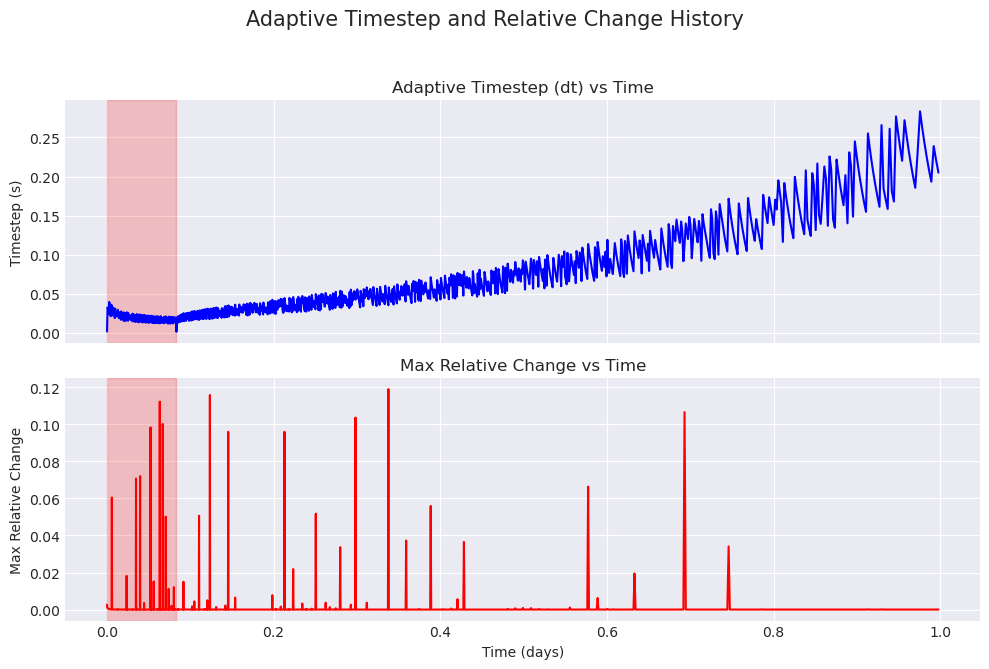

In [72]:
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Adaptive Timestep and Relative Change History', fontsize=15)

# Plot dt_history
ax[0].plot(time_days, dt_history, color='blue')
ax[0].set_ylabel('Timestep (s)')
ax[0].set_title('Adaptive Timestep (dt) vs Time')
ax[0].axvspan(0, t_irr/86400, color='red', alpha=0.2)
ax[0].grid(True)

# Plot rel_change_history
ax[1].plot(time_days, rel_change_history, color='red')
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Max Relative Change')
ax[1].set_title('Max Relative Change vs Time')
ax[1].axvspan(0, t_irr/86400, color='red', alpha=0.2)
ax[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()